In [1]:
import os
import shutil
import argparse

import warnings

warnings.filterwarnings(
    "ignore",
    module="pydantic"
)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.serialization import add_safe_globals
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal

import torchvision.models as models
import torchvision.transforms as T
import torchvision.transforms.functional as F

from PIL import Image

from sklearn.model_selection import train_test_split
from timm.models.vision_transformer import VisionTransformer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

Loading the dataset:

In [2]:
df = pd.read_csv("/kaggle/input/chexchonet/chexchonet-a-chest-radiograph-dataset-with-gold-standard-echocardiography-labels-1.0.0/metadata.csv")

Creating the subset we'll be working with:

In [3]:
subset_path = "/kaggle/working/dlv_dataset"

if os.path.exists(subset_path):
    shutil.rmtree(subset_path)

os.makedirs(subset_path, exist_ok=True)
os.makedirs(os.path.join(subset_path, "images"), exist_ok=True)

# only dlv confirmed pacients and healthy ones
healthy      = df[(df.slvh == 0) & (df.dlv == 0)].sample(3670, random_state=42)
dlv_only     = df[(df.slvh == 0) & (df.dlv == 1)].sample(3670, random_state=42)

df_dlv_subset = pd.concat([healthy, dlv_only])

src_img_dir = "/kaggle/input/chexchonet/chexchonet-a-chest-radiograph-dataset-with-gold-standard-echocardiography-labels-1.0.0/images/"
dst_img_dir = os.path.join(subset_path, "images")

for _, row in df_dlv_subset.iterrows():
    src = os.path.join(src_img_dir, row["cxr_filename"])
    dst = os.path.join(dst_img_dir, row["cxr_filename"])
    shutil.copy(src, dst)

df_dlv_subset.to_csv(os.path.join(subset_path, "metadata_subset.csv"), index=False)

Creting the training, validation and testing sets:

In [6]:
train_df, temp_df = train_test_split(
    df_dlv_subset,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=df_dlv_subset["dlv"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=temp_df["dlv"]
)

Class used for inputting the ViT:

In [7]:
class CheXchoNet(Dataset):
    def __init__(self, df, root_img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_img_dir = root_img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_img_dir, row["cxr_filename"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["dlv"], dtype=torch.float32)
        return img, label

Image preprocessing and augmentations steps for training, validation and testing sets:

In [8]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

train_transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomResizedCrop(size=224, scale=(0.8, 1.0), ratio=(0.9, 1.1))
])

Creating the corresponding DataLoaders:

In [10]:
root_img_dir = "/kaggle/working/dlv_dataset/images"

train_loader = DataLoader(
    CheXchoNet(train_df, root_img_dir, train_transform),
    batch_size=32, shuffle=True, num_workers=2
)

val_loader = DataLoader(
    CheXchoNet(val_df, root_img_dir, transform),
    batch_size=32, shuffle=False, num_workers=2
)

test_loader = DataLoader(
    CheXchoNet(test_df, root_img_dir, transform),
    batch_size=32, shuffle=False, num_workers=2
)

Loading the pretrained weights for the ViT:

In [12]:
weights_path = "/kaggle/input/vit-weights/vit-s_CXR_0.3M_mae.pth"

add_safe_globals([argparse.Namespace])
state = torch.load(weights_path, map_location="cpu", weights_only=False)

The vision transformer architecture used:

In [13]:
def vit_small_patch16(num_classes=0):
    model = VisionTransformer(
        patch_size=16,
        embed_dim=384,
        depth=12,
        num_heads=6,
        mlp_ratio=4,
        qkv_bias=True,
        norm_layer=nn.LayerNorm,
        num_classes=num_classes
    )
    return model

encoder = vit_small_patch16()

# loading the weights
encoder.load_state_dict(state["model"], strict=False)

# freezing the weights
for param in encoder.parameters():
    param.requires_grad = False

The MLP head used to classify:

In [14]:
class DLVClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

        self.mlp = nn.Sequential(
            nn.Linear(384, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.mlp(x)

model = DLVClassifier(encoder).cuda()

Optimizer and criterion used with the MLP:

In [15]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Linear learning rate warmup with cosine decay:

In [16]:
epochs = 20
warmup_epochs = 2

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        return float(current_epoch) / float(max(1, warmup_epochs))
    progress = float(current_epoch - warmup_epochs) / float(max(1, epochs - warmup_epochs))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

Helper functions for the training loop:

In [17]:
def eval_loader(model, loader, criterion=None, device="cuda"):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x).squeeze(1)
            probs = torch.sigmoid(logits)

            probs_list.append(probs.detach().cpu())
            labels_list.append(y.detach().cpu())

            if criterion is not None:
                loss = criterion(logits, y)
                total_loss += loss.item()
                n_batches += 1

    probs_np = torch.cat(probs_list).numpy()
    labels_np = torch.cat(labels_list).numpy()

    auroc = roc_auc_score(labels_np, probs_np)

    avg_loss = (total_loss / n_batches) if (criterion is not None and n_batches > 0) else None
    return avg_loss, auroc, probs_np, labels_np

def train_one_epoch(model, loader, optimizer, criterion, device="cuda"):
    model.train()
    running_loss = 0.0

    probs_list = []
    labels_list = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(logits)
        probs_list.append(probs.detach().cpu())
        labels_list.append(y.detach().cpu())

    avg_loss = running_loss / len(loader)
    probs_np = torch.cat(probs_list).numpy()
    labels_np = torch.cat(labels_list).numpy()
    auroc = roc_auc_score(labels_np, probs_np)

    return avg_loss, auroc

The training loop:

In [18]:
best_auc = 0
patience = 5
patience_counter = 0

train_losses, val_losses = [], []
train_aucs, val_aucs = [], []

for epoch in range(epochs):
    train_loss, train_auc = train_one_epoch(model, train_loader, optimizer, criterion, device="cuda")
    scheduler.step()

    val_loss, val_auc, _, _ = eval_loader(model, val_loader, criterion=criterion, device="cuda")

    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train AUROC: {train_auc:.4f} | "
        f"Val AUROC: {val_auc:.4f}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), "best_dlv_model.pth")
        print(">> New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/20 | Train Loss: 0.6936 | Val Loss: 0.6934 | Train AUROC: 0.4982 | Val AUROC: 0.4879
>> New best model saved!
Epoch 2/20 | Train Loss: 0.6861 | Val Loss: 0.6803 | Train AUROC: 0.5894 | Val AUROC: 0.6200
>> New best model saved!
Epoch 3/20 | Train Loss: 0.6481 | Val Loss: 0.6493 | Train AUROC: 0.6784 | Val AUROC: 0.6686
>> New best model saved!
Epoch 4/20 | Train Loss: 0.6171 | Val Loss: 0.6358 | Train AUROC: 0.7201 | Val AUROC: 0.7072
>> New best model saved!
Epoch 5/20 | Train Loss: 0.6029 | Val Loss: 0.6101 | Train AUROC: 0.7370 | Val AUROC: 0.7251
>> New best model saved!
Epoch 6/20 | Train Loss: 0.5960 | Val Loss: 0.6000 | Train AUROC: 0.7453 | Val AUROC: 0.7341
>> New best model saved!
Epoch 7/20 | Train Loss: 0.5860 | Val Loss: 0.5900 | Train AUROC: 0.7581 | Val AUROC: 0.7463
>> New best model saved!
Epoch 8/20 | Train Loss: 0.5825 | Val Loss: 0.5906 | Train AUROC: 0.7604 | Val AUROC: 0.7518
>> New best model saved!
Epoch 9/20 | Train Loss: 0.5748 | Val Loss: 0.5882 | Tra

Saving the best model after the training phase:

In [19]:
best_model = DLVClassifier(encoder).cuda()
best_model.load_state_dict(torch.load("best_dlv_model.pth"))

<All keys matched successfully>

Running the model on the test set:

In [20]:
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.cuda()
        y = y.cuda()

        logits = best_model(x).squeeze(1)
        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).long()

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

Visualizing the training and test results:

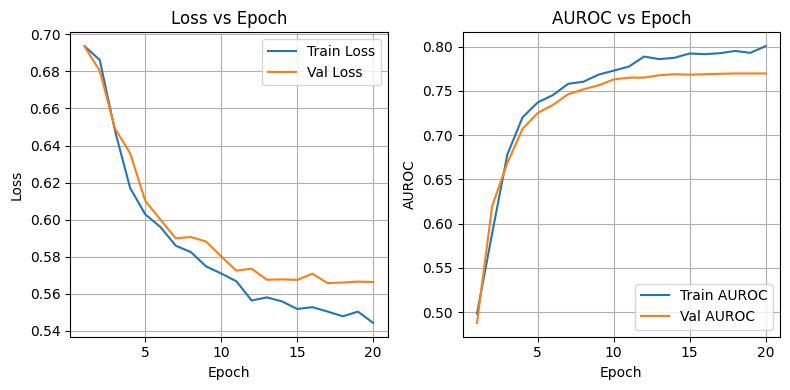

In [22]:
epochs_range = range(1, len(train_aucs) + 1)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_aucs, label='Train AUROC')
plt.plot(epochs_range, val_aucs, label='Val AUROC')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.title('AUROC vs Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
test_auc = roc_auc_score(all_labels, all_probs)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)

print("\nTest Set Performance")
print(f"AUROC:     {test_auc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")


Test Set Performance
AUROC:     0.7887
Precision: 0.7074
Recall:    0.7268
F1-score:  0.7170
